In [1]:
# Grid size
ROWS = 3
COLS = 3

# Starting position of the agent
agent_position = (2, 2)

# Goal and danger positions
goal = (0, 2)
danger = (1, 1)

print("Agent:", agent_position)
print("Goal:", goal)
print("Danger:", danger)

Agent: (2, 2)
Goal: (0, 2)
Danger: (1, 1)


In [2]:
actions = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT"
}

print(actions)

{0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT'}


In [3]:
def move(position, action):
    row, col = position
    if action == 0:      # UP
        row -= 1
    elif action == 1:    # DOWN
        row += 1
    elif action == 2:    # LEFT
        col -= 1
    elif action == 3:    # RIGHT
        col += 1
    # Don't allow the agent to leave the grid
    row = max(0, min(row, ROWS - 1))
    col = max(0, min(col, COLS - 1))

    return (row, col)

In [4]:
position = (2, 2)

new_position = move(position, 0)

print("Old position:", position)
print("Action:", actions[0])
print("New position:", new_position)

Old position: (2, 2)
Action: UP
New position: (1, 2)


In [5]:
def get_reward(position):

    if position == goal:
        return 10

    elif position == danger:
        return -10

    else:
        return -1

In [6]:
print(get_reward((0, 2)))  # Goal
print(get_reward((1, 1)))  # Danger
print(get_reward((1, 2)))  # Normal

10
-10
-1


In [7]:
position = (2, 2)

action = 0

new_position = move(position, action)

reward = get_reward(new_position)

print("State:", position)
print("Action:", actions[action])
print("New State:", new_position)
print("Reward:", reward)

State: (2, 2)
Action: UP
New State: (1, 2)
Reward: -1


In [8]:
import random
action = random.choice([0, 1, 2, 3])
print("Agent chose:", actions[action])

Agent chose: UP


In [9]:
position = (2, 2)

# Agent randomly chooses an action
action = random.choice([0, 1, 2, 3])

# Environment moves the agent
new_position = move(position, action)

# Environment gives reward
reward = get_reward(new_position)

print("Current state :", position)
print("Action        :", actions[action])
print("New state     :", new_position)
print("Reward        :", reward)

Current state : (2, 2)
Action        : LEFT
New state     : (2, 1)
Reward        : -1


In [10]:
position = (2, 2)

total_reward = 0

for step in range(20):

    # Random action
    action = random.choice([0, 1, 2, 3])

    # Move
    new_position = move(position, action)

    # Get reward
    reward = get_reward(new_position)

    print(
        f"Step {step + 1}: "
        f"{position} → {actions[action]} → "
        f"{new_position}, reward = {reward}"
    )

    total_reward += reward
    position = new_position

    # Stop if goal or danger is reached
    if position == goal:
        print("🏆 Goal reached!")
        break

    if position == danger:
        print("💀 Agent died!")
        break

print("Total reward:", total_reward)

Step 1: (2, 2) → DOWN → (2, 2), reward = -1
Step 2: (2, 2) → DOWN → (2, 2), reward = -1
Step 3: (2, 2) → UP → (1, 2), reward = -1
Step 4: (1, 2) → RIGHT → (1, 2), reward = -1
Step 5: (1, 2) → UP → (0, 2), reward = 10
🏆 Goal reached!
Total reward: 6


In [11]:
successes = 0
deaths = 0

for episode in range(1000):

    position = (2, 2)

    for step in range(20):

        action = random.choice([0, 1, 2, 3])

        new_position = move(position, action)

        reward = get_reward(new_position)

        position = new_position

        if position == goal:
            successes += 1
            break

        if position == danger:
            deaths += 1
            break

print("Successful episodes:", successes)
print("Deaths:", deaths)

Successful episodes: 275
Deaths: 685


Creating the Q-Table

In [12]:
import numpy as np

q_table = np.zeros((ROWS * COLS, 4))

print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [13]:
def state_to_index(position):
    row, col = position
    return row * COLS + col

In [14]:
print(state_to_index((0, 0)))
print(state_to_index((0, 1)))
print(state_to_index((1, 0)))
print(state_to_index((2, 2)))

0
1
3
8


In [15]:
state = state_to_index((2, 2))

print("State index:", state)
print("Q-values:", q_table[state])

State index: 8
Q-values: [0. 0. 0. 0.]


In [16]:
alpha = 0.1
gamma = 0.9

In [17]:
state = (2, 2)
action = 0  # UP

new_state = move(state, action)
reward = get_reward(new_state)

state_index = state_to_index(state)
new_state_index = state_to_index(new_state)

old_q = q_table[state_index, action]

best_future_q = np.max(q_table[new_state_index])

new_q = old_q + alpha * (
    reward + gamma * best_future_q - old_q
)

q_table[state_index, action] = new_q

print("New Q-value:", new_q)

New Q-value: -0.1


In [18]:
import numpy as np
import random

# ==========================================
# 1. ENVIRONMENT
# ==========================================

ROWS = 3
COLS = 3

start = (2, 2)
goal = (0, 2)
danger = (1, 1)

actions = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT"
}


# ==========================================
# 2. MOVE FUNCTION
# ==========================================

def move(position, action):

    row, col = position

    if action == 0:        # UP
        row -= 1

    elif action == 1:      # DOWN
        row += 1

    elif action == 2:      # LEFT
        col -= 1

    elif action == 3:      # RIGHT
        col += 1

    # Keep agent inside grid
    row = max(0, min(row, ROWS - 1))
    col = max(0, min(col, COLS - 1))

    return (row, col)


# ==========================================
# 3. REWARD FUNCTION
# ==========================================

def get_reward(position):

    if position == goal:
        return 10

    elif position == danger:
        return -10

    else:
        return -1


# ==========================================
# 4. CONVERT STATE TO TABLE INDEX
# ==========================================

def state_to_index(position):

    row, col = position

    return row * COLS + col


# ==========================================
# 5. CREATE Q-TABLE
# ==========================================

q_table = np.zeros((ROWS * COLS, len(actions)))

print("Initial Q-table:")
print(q_table)


# ==========================================
# 6. HYPERPARAMETERS
# ==========================================

alpha = 0.1       # Learning rate
gamma = 0.9       # Discount factor
epsilon = 1.0     # Exploration probability

epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 5000


# ==========================================
# 7. TRAINING
# ==========================================

rewards_per_episode = []

for episode in range(episodes):

    # Start a new episode
    position = start

    total_reward = 0

    for step in range(50):

        state_index = state_to_index(position)

        # ----------------------------------
        # Choose action
        # ----------------------------------

        if random.random() < epsilon:

            # Explore
            action = random.choice(list(actions.keys()))

        else:

            # Exploit
            action = np.argmax(q_table[state_index])

        # ----------------------------------
        # Take action
        # ----------------------------------

        new_position = move(position, action)

        # ----------------------------------
        # Receive reward
        # ----------------------------------

        reward = get_reward(new_position)

        total_reward += reward

        # ----------------------------------
        # Convert new state
        # ----------------------------------

        new_state_index = state_to_index(new_position)

        # ----------------------------------
        # Q-learning update
        # ----------------------------------

        old_q = q_table[state_index, action]

        best_future_q = np.max(q_table[new_state_index])

        new_q = old_q + alpha * (
            reward
            + gamma * best_future_q
            - old_q
        )

        q_table[state_index, action] = new_q

        # Move to new state
        position = new_position

        # ----------------------------------
        # End episode
        # ----------------------------------

        if position == goal:
            break

        if position == danger:
            break

    rewards_per_episode.append(total_reward)

    # Reduce exploration
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# ==========================================
# 8. PRINT RESULTS
# ==========================================

print("\nTraining finished!")

print("\nFinal Q-table:")
print(np.round(q_table, 2))

print("\nFinal epsilon:", epsilon)

Initial Q-table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Training finished!

Final Q-table:
[[-0.2  -0.31 -0.1  -0.1 ]
 [ 0.    0.    0.    1.  ]
 [ 0.    0.    0.    0.  ]
 [-0.36  0.07 -0.28 -4.1 ]
 [ 0.    0.    0.    0.  ]
 [10.    6.2  -9.99  7.94]
 [-0.85 -0.21 -0.04  2.32]
 [-8.5   3.15 -0.1   6.2 ]
 [ 8.    6.19  4.57  6.2 ]]

Final epsilon: 0.01


In [19]:
if random.random() < epsilon:
    action = random.choice(list(actions.keys()))
else:
    action = np.argmax(q_table[state_index])

In [20]:
position = start

print("Learned path:")

for step in range(20):

    state_index = state_to_index(position)

    action = np.argmax(q_table[state_index])

    new_position = move(position, action)

    print(
        position,
        "→",
        actions[action],
        "→",
        new_position
    )

    position = new_position

    if position == goal:
        print("\n🏆 Goal reached!")
        break

    if position == danger:
        print("\n💀 Agent died!")
        break

Learned path:
(2, 2) → UP → (1, 2)
(1, 2) → UP → (0, 2)

🏆 Goal reached!


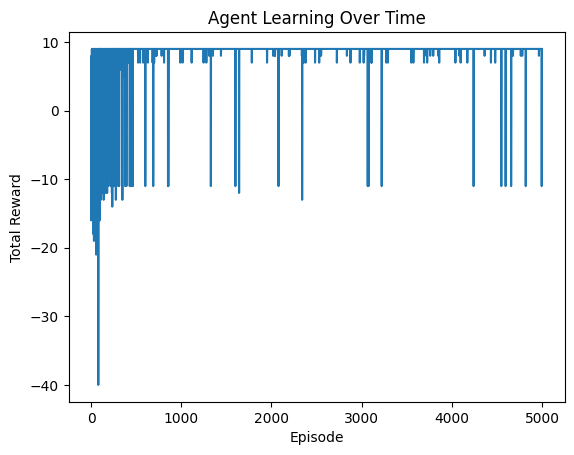

In [21]:
import matplotlib.pyplot as plt

plt.plot(rewards_per_episode)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Agent Learning Over Time")

plt.show()